Importing Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [5]:
file_path = "../data/raw/Online Retail.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully")
except Exception as e:
    print("Error loading data:",e)

df.head()

Data loaded successfully


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# Shape of dataset
print("Shape:", df.shape)

Shape: (541909, 8)


In [7]:
# Check column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
# Checking if dataset is empty
print("\nIs dataset empty?", df.empty)


Is dataset empty? False


In [9]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [10]:
# Dataset Inspection
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [11]:
# Are there any missing values?
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

## Data Cleaning

The goal of this project is to segment identifiable customers based on actual purchase behavior.

Cleaning decisions:
- Rows without 'CustomerID' are removed because customer-level segmentation requires a customer identifier.
- Cancelled invoices are removed because they do not represent completed purchases.
- Negative or zero quantities are removed because they represent returns or invalid purchases.
- Zero or negative unit prices are removed because they do not represent valid revenue-generating transactions.
- Exact duplicate rows are removed to avoid double-counting transactions.

In [12]:
# Creating a copy before cleaning
df_clean = df.copy()
print("Original shape:", df_clean.shape)

Original shape: (541909, 8)


In [13]:
# Dropping exact duplicate rows
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)

After removing duplicates: (536641, 8)


In [14]:
# Removing rows with missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])
print("After removing missing CustomerID:", df_clean.shape)


After removing missing CustomerID: (401604, 8)


In [15]:
# Removing cancelled invoices
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print("After removing non-positive quantities:", df_clean.shape)


After removing non-positive quantities: (392732, 8)


In [16]:
# Remove invalid prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]
print("After removing non-positive prices:", df_clean.shape)

After removing non-positive prices: (392692, 8)


In [17]:
# Remove invalid quantities
df_clean = df_clean[df_clean["Quantity"] > 0]
print("After removing non-positive quantities:", df_clean.shape)

After removing non-positive quantities: (392692, 8)


In [18]:
# Converting CustomerID to string
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)

In [19]:
# Creating total spend column
df_clean["TotalSpend"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [20]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  str           
 7   Country      392692 non-null  str           
 8   TotalSpend   392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 30.0+ MB


In [21]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,TotalSpend
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,180.492832,NaN,22.241836,311.099224


## Week 2 Next Steps

- Build RFM features (Recency, Frequency, Monetary)
- Aggregate data to customer level
- Analyze distributions and apply transformations

## RFM Engineering

To segment customers, transaction-level data is aggregated into customer-level features using RFM analysis:

- **Recency:** Number of days since the customer's last purchase
- **Frequency:** Number of unique transactions made by customer
- **Monetary:** Total amount of spent by the customer

These features summarize customer behavior and will be used for clustering.

In [22]:
# referencing date (one day last transactions)
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [23]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalSpend": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [24]:
print("RFM shape:", rfm.shape)
rfm.describe()

RFM shape: (4338, 4)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [25]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

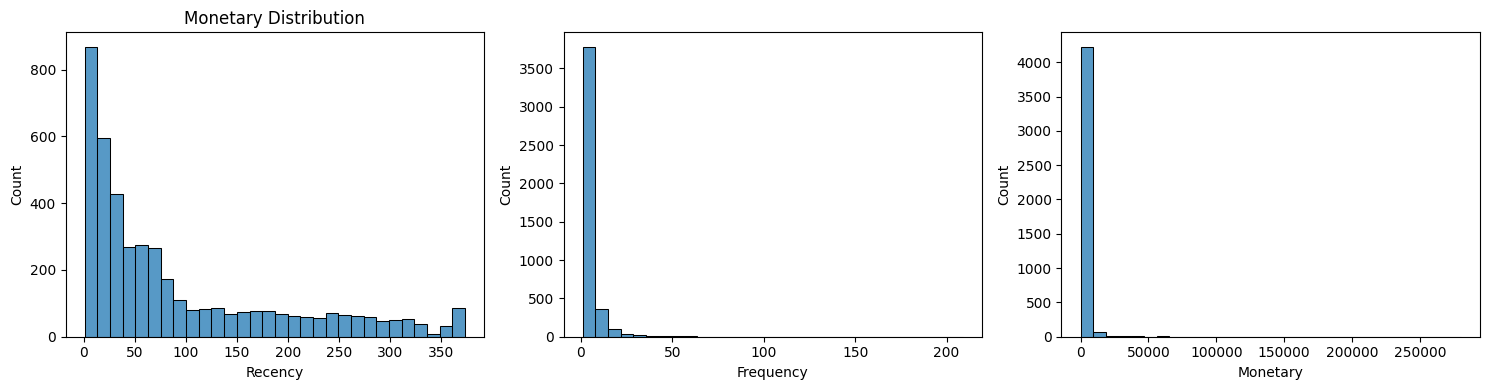

In [26]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[0].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[0].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

## Data Transformation

RFM variables are highly skewed, especially Monetary and Frequency.

To reduce the impact of extreme values and make clustering more effective, a log transformation is applied.

This helps:
- Compress large values
- Improve cluster separation
- Prevent high spenders from dominating the model

In [27]:
# Applying log transformation
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


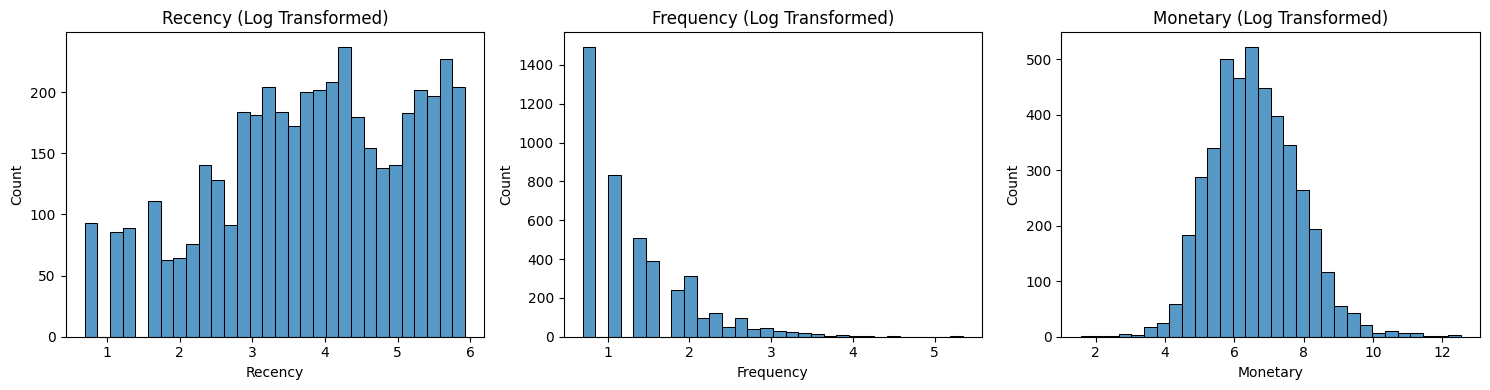

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm_log["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency (Log Transformed)")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency (Log Transformed)")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary (Log Transformed)")

plt.tight_layout()
plt.show()

## Next Steps

The following steps will be completed in the next stage of the project:

### 1. Clustering (K-Means)
- Use the Elbow Method to determine the optimal number of clusters
- Validate using the Silhoutte Score
- Train K-Means model and assign cluster labels to customers

### 2. Cluster Profiling
- Analyze average Recency, Frequency, and Monetary values per cluster
- Compare customer count and revenue contribution across segments

### 3. Business Intrepretation
- Assign meaningful labels to each customer segment
- Identify high-value, at-risk, and low-value customers

### 4. Data Export
- Export final dataset with cluster labels for further use

## 5. Dashboard Development
- Build an interactive dashboard to visualize customer segment
- Show revenue contribution and behavioral differences between segments

## Feature Scaling

After log transformation, the RFM features are standardized using 'StandardScaler'.

This ensures that:
- All variables contribute equally to clustering
- Features with larger values do not dominate the K-means algorithm.

In [29]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns = ["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [30]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


In [31]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state = 42,
        n_init = 10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

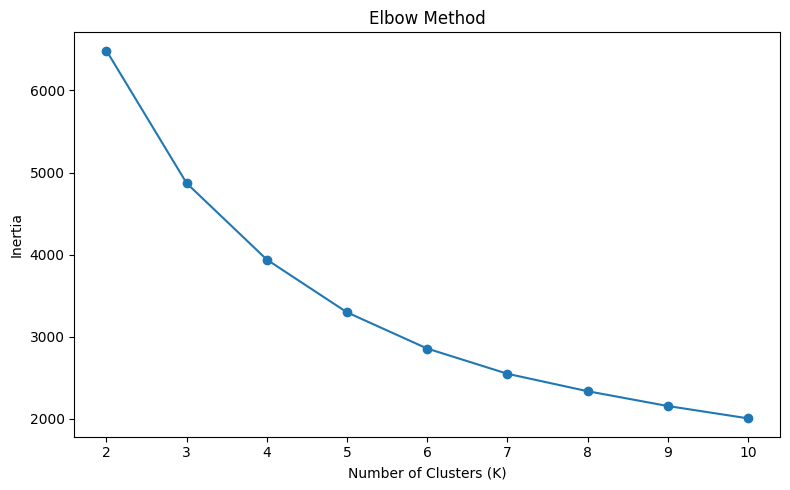

In [32]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## Silhoutte Score

The Silhoutte Score is used to evaluate how well-separated the clusters are.

A higher score indicates:
- better separation between clusters
- stronger clustering structure

In [33]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

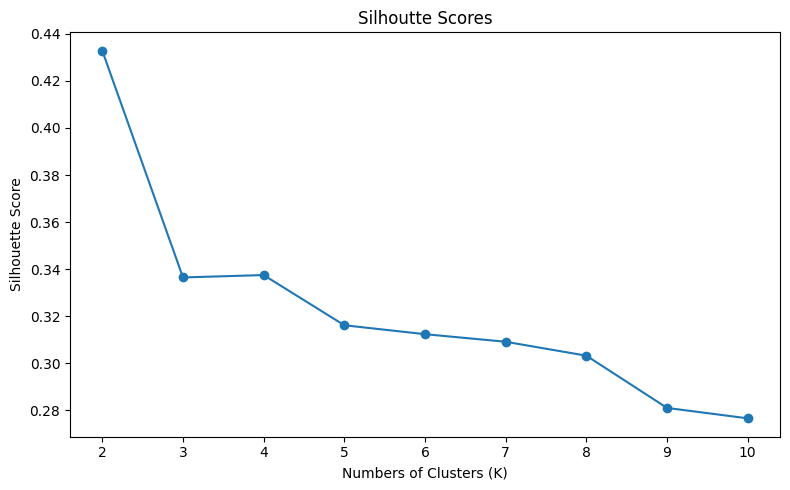

In [34]:
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker="o")

plt.title("Silhoutte Scores")
plt.xlabel("Numbers of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

## Final K-Means Model

Based on the Elbow method and Silhoutte Score, the final numbers of clusters were chosen as:

- K = 4

This provides a balance between:
- clustering equality
- interpretability
- business usefulness

In [35]:
final_k = 4

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


In [36]:
rfm["Cluster"].value_counts()

Cluster
1    1622
3    1166
2     837
0     713
Name: count, dtype: int64

## Clustering Summary

K-Means clustering was applied to the transformed RFM dataset.

To determine the optimal number of clusters:
- The Elbow Method was used to evaluate inertia
- Silhouette Score was used to access cluster quality

A final value of 'K = 4' was selected as a balance between:
- model quality
- interpretability
- business usefulness

Each customer was assigned to one of the four clusters for further analysis.

## Cluster Profiling

After clustering, each customer group is analyzed based on:

- Average Recency
- Average Frequency
- Average Monetary Value
- Number of Customers

This helps interpret the behavioral characteristics of each segment.

In [37]:
cluster_profile = rfm.groupby("Cluster").agg({
    "CustomerID": "count",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": ["mean", "sum"]
}).round(2)

cluster_profile.columns = [
    "Customer_Count",
    "Avg_Recency",
    "Avg_Frequency",
    "Avg_Monetary",
    "Total_Revenue"
]

cluster_profile = cluster_profile.reset_index()

cluster_profile

,Cluster,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
0,0,713,12.17,13.75,8088.02,5766757.07
1,1,1622,181.51,1.32,341.00,553099.77
2,2,837,17.70,2.19,557.32,466479.03
3,3,1166,71.64,4.08,1801.78,2100873.02


In [38]:
segment_map = {
    0 : "High-Value Loyal Customers",
    1 : "Inactive Low-Value Customers",
    2 : "Recent Occassional Customers",
    3 : "Mid-Value Regular Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Mid-Value Regular Customers
1,12347,2,7,4310.00,0,High-Value Loyal Customers
2,12348,75,4,1797.24,3,Mid-Value Regular Customers
3,12349,19,1,1757.55,2,Recent Occassional Customers
4,12350,310,1,334.40,1,Inactive Low-Value Customers
